In [ ]:
#Assignment 2
#NAME:Pankaj Soni
#Roll Number:2501940044
#Course Code & Title: Deep learning Architecture and Techniques(ETMMDL274)
#MCA(AI&ML)

In [8]:
from google.colab import files
uploaded = files.upload()

Saving cifar-10-python.tar.gz to cifar-10-python.tar (1).gz


In [9]:
#IMPORT
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import random
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

In [10]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version : 2.19.0
Keras version      : 3.10.0
GPU available      : False


In [11]:
# ── Load CIFAR-10 ─────────────────────────────────────────────────────────────
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
NUM_CLASSES = len(CLASS_NAMES)

print('Full training set :', X_train_full.shape, y_train_full.shape)
print('Test set          :', X_test.shape,       y_test.shape)
print('Pixel range       :', X_train_full.min(), '-', X_train_full.max())

Full training set : (50000, 32, 32, 3) (50000, 1)
Test set          : (10000, 32, 32, 3) (10000, 1)
Pixel range       : 0 - 255


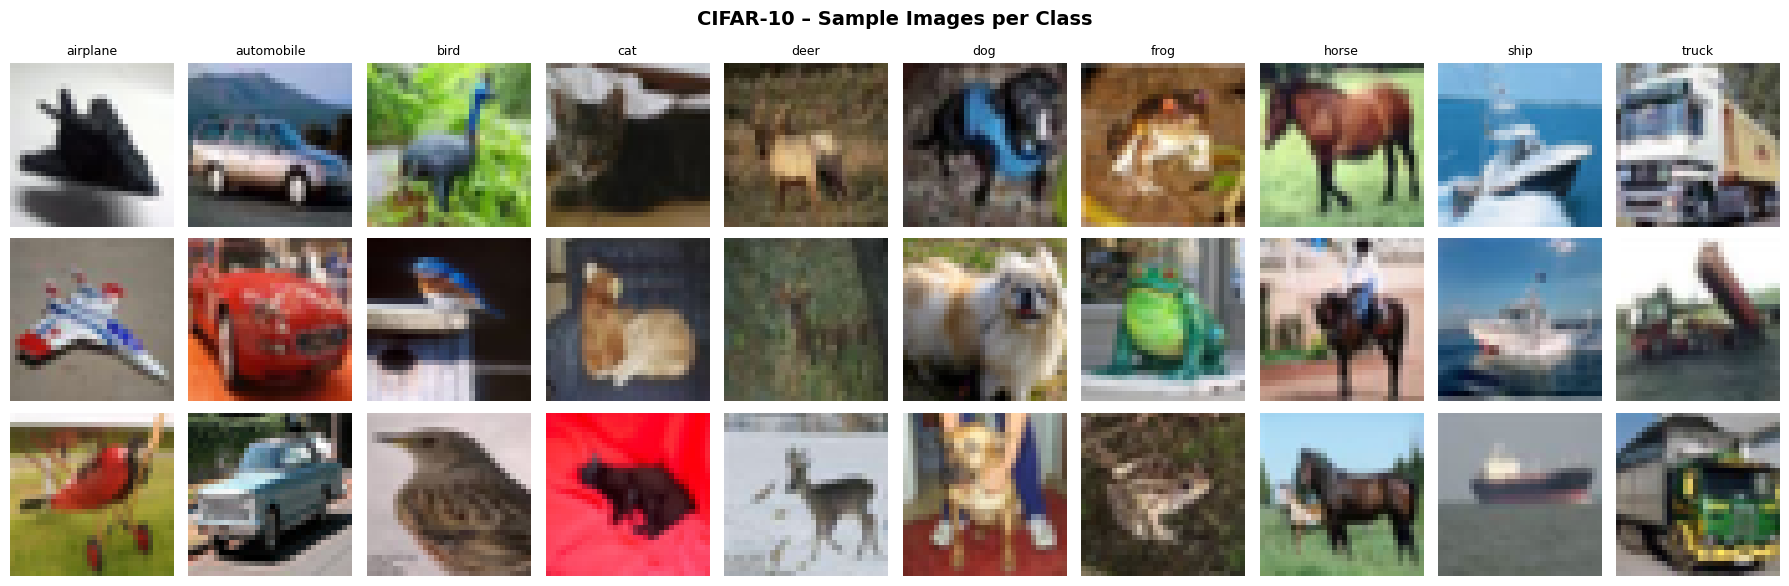

In [5]:
# ── Visualise a sample grid ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(18, 6))
fig.suptitle('CIFAR-10 – Sample Images per Class', fontsize=14, fontweight='bold')
for col, cls in enumerate(range(NUM_CLASSES)):
    idxs = np.where(y_train_full.flatten() == cls)[0][:3]
    for row, idx in enumerate(idxs):
        axes[row, col].imshow(X_train_full[idx])
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[cls], fontsize=9)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

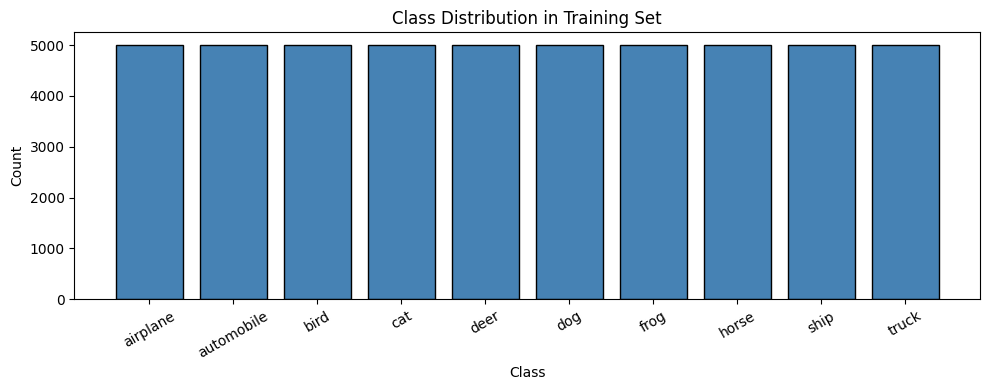

Each class has 5000 images → balanced dataset


In [6]:
# ── Class distribution ────────────────────────────────────────────────────────
unique, counts = np.unique(y_train_full, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='black')
plt.title('Class Distribution in Training Set')
plt.ylabel('Count'); plt.xlabel('Class')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Each class has', counts[0], 'images → balanced dataset')

In [12]:
#IMAGE PREPROCESSING
# ── Train / Validation split (80 / 20 of the 50 k training set) ───────────────
VAL_SPLIT = 0.20
split_idx  = int(len(X_train_full) * (1 - VAL_SPLIT))

X_train, X_val = X_train_full[:split_idx], X_train_full[split_idx:]
y_train, y_val = y_train_full[:split_idx], y_train_full[split_idx:]

# ── Normalise pixel values to [0, 1] ─────────────────────────────────────────
X_train = X_train.astype('float32') / 255.0
X_val   = X_val.astype('float32')   / 255.0
X_test  = X_test.astype('float32')  / 255.0

# ── One-hot encode labels ─────────────────────────────────────────────────────
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f'Train   : {X_train.shape}  |  Val  : {X_val.shape}  |  Test : {X_test.shape}')
print(f'Pixel range after normalisation: {X_train.min():.1f} – {X_train.max():.1f}')

Train   : (40000, 32, 32, 3)  |  Val  : (10000, 32, 32, 3)  |  Test : (10000, 32, 32, 3)
Pixel range after normalisation: 0.0 – 1.0


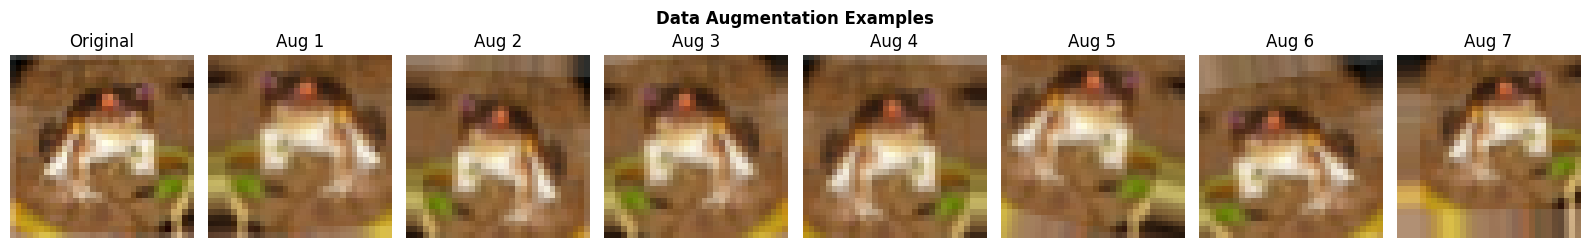

Augmentation techniques: rotation, shift, flip, zoom, shear


In [13]:
#DATA AUGMENTATION
# ── Augmentation pipeline (applied only during training) ─────────────────────
datagen = ImageDataGenerator(
    rotation_range      = 15,     # rotate ±15°
    width_shift_range   = 0.1,    # shift horizontally ±10%
    height_shift_range  = 0.1,    # shift vertically   ±10%
    horizontal_flip     = True,   # random horizontal flip
    zoom_range          = 0.1,    # zoom ±10%
    shear_range         = 0.1,    # shear ±10°
    fill_mode           = 'nearest'
)
datagen.fit(X_train)

# ── Visualise augmented images ────────────────────────────────────────────────
sample_img = X_train[0:1]
fig, axes  = plt.subplots(1, 8, figsize=(16, 2.5))
axes[0].imshow(sample_img[0]); axes[0].set_title('Original'); axes[0].axis('off')
aug_iter = datagen.flow(sample_img, batch_size=1)
for i in range(1, 8):
    aug_img = next(aug_iter)[0]
    axes[i].imshow(np.clip(aug_img, 0, 1))
    axes[i].set_title(f'Aug {i}'); axes[i].axis('off')
plt.suptitle('Data Augmentation Examples', fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Augmentation techniques: rotation, shift, flip, zoom, shear')

In [14]:
#CUATOM CNN ARCHITECTURE
def build_custom_cnn(input_shape=(32, 32, 3), num_classes=10):

    inputs = keras.Input(shape=input_shape, name='input')

    # ── Block 1 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4), name='conv1_1')(inputs)
    x = layers.BatchNormalization(name='bn1_1')(x)
    x = layers.Activation('relu', name='relu1_1')(x)
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4), name='conv1_2')(x)
    x = layers.BatchNormalization(name='bn1_2')(x)
    x = layers.Activation('relu', name='relu1_2')(x)
    x = layers.MaxPooling2D((2,2), name='pool1')(x)
    x = layers.Dropout(0.25, name='drop1')(x)

    # ── Block 2 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4), name='conv2_1')(x)
    x = layers.BatchNormalization(name='bn2_1')(x)
    x = layers.Activation('relu', name='relu2_1')(x)
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4), name='conv2_2')(x)
    x = layers.BatchNormalization(name='bn2_2')(x)
    x = layers.Activation('relu', name='relu2_2')(x)
    x = layers.MaxPooling2D((2,2), name='pool2')(x)
    x = layers.Dropout(0.25, name='drop2')(x)

    # ── Block 3 ──────────────────────────────────────────────────────────────
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4), name='conv3_1')(x)
    x = layers.BatchNormalization(name='bn3_1')(x)
    x = layers.Activation('relu', name='relu3_1')(x)
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(1e-4), name='conv3_2')(x)
    x = layers.BatchNormalization(name='bn3_2')(x)
    x = layers.Activation('relu', name='relu3_2')(x)
    x = layers.MaxPooling2D((2,2), name='pool3')(x)
    x = layers.Dropout(0.25, name='drop3')(x)

    # ── Fully-Connected Head ──────────────────────────────────────────────────
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), name='fc1')(x)
    x = layers.BatchNormalization(name='bn_fc')(x)
    x = layers.Activation('relu', name='relu_fc')(x)
    x = layers.Dropout(0.5, name='drop_fc')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inputs, outputs, name='Custom_CNN')


custom_cnn = build_custom_cnn()
custom_cnn.summary()

# ── Compile ───────────────────────────────────────────────────────────────────
custom_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('\nCustom CNN compiled successfully.')

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_1 (Activation)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1_2 (Activation)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_1 (Activation)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2_2 (Activation)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_1 (Activation)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3_2 (Activation)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 4, 4, 128)      │             

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)


Custom CNN compiled successfully.


In [17]:
#TRAIN THE CUSTOM CNN
BATCH_SIZE  = 64
EPOCHS_CNN  = 1

callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history_cnn = custom_cnn.fit(
    datagen.flow(X_train, y_train_oh, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch = len(X_train) // BATCH_SIZE,
    epochs          = EPOCHS_CNN,
    validation_data = (X_val, y_val_oh),
    callbacks       = callbacks_cnn,
    verbose         = 1
)

print('\nCustom CNN training complete.')

625/625 ━━━━━━━━━━━━━━━━━━━━ 351s 561ms/step - accuracy: 0.6130 - loss: 1.1947 - val_accuracy: 0.4635 - val_loss: 1.8291 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.

Custom CNN training complete.


In [18]:
#TRANSFER LEARNING WITH MOBILENETV2
# CIFAR-10 images are 32×32; MobileNetV2 requires at least 96×96.
# We use a Resizing layer inside the model so the pipeline is self-contained.

TARGET_SIZE = 96  # upscale to 96×96

def build_transfer_model(input_shape=(32, 32, 3), num_classes=10, fine_tune_at=100):

    inputs = keras.Input(shape=input_shape, name='input')

    # Upscale CIFAR-10 images to 96×96 for MobileNetV2
    x = layers.Resizing(TARGET_SIZE, TARGET_SIZE, name='resize')(inputs)

    # MobileNetV2 expects inputs in [-1, 1]
    x = layers.Lambda(lambda t: tf.keras.applications.mobilenet_v2.preprocess_input(t * 255.0),
                      name='mobilenet_preprocess')(x)

    base_model = MobileNetV2(
        input_shape=(TARGET_SIZE, TARGET_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False   # Stage 1: freeze all

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(256, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.5, name='drop')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')
    return model, base_model


transfer_model, base_model = build_transfer_model()
transfer_model.summary()

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('\nTransfer model compiled.')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize (Resizing)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocess (Lambda)   │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Transfer model compiled.


In [20]:
# ── Stage 1: Feature Extraction ───────────────────────────────────────────────
EPOCHS_FE = 1

callbacks_fe = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history_fe = transfer_model.fit(
    datagen.flow(X_train, y_train_oh, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch = len(X_train) // BATCH_SIZE,
    epochs          = EPOCHS_FE,
    validation_data = (X_val, y_val_oh),
    callbacks       = callbacks_fe,
    verbose         = 1
)

print('\nStage 1 (feature extraction) complete.')

625/625 ━━━━━━━━━━━━━━━━━━━━ 355s 568ms/step - accuracy: 0.7245 - loss: 0.7958 - val_accuracy: 0.8271 - val_loss: 0.4941 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 1.

Stage 1 (feature extraction) complete.


In [27]:
# ── Stage 2: Fine-Tuning ──────────────────────────────────────────────────────
# Unfreeze top layers of MobileNetV2 for gentle fine-tuning
FINE_TUNE_AT = 1   # unfreeze layers from index 100 onwards

base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Fine-tuning {trainable_count} layers of MobileNetV2 (from layer {FINE_TUNE_AT})')

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),   # lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FT = 1

callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]

history_ft = transfer_model.fit(
    datagen.flow(X_train, y_train_oh, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch = len(X_train) // BATCH_SIZE,
    epochs          = EPOCHS_FT,
    validation_data = (X_val, y_val_oh),
    callbacks       = callbacks_ft,
    verbose         = 1
)

print('\nStage 2 (fine-tuning) complete.')

Fine-tuning 54 layers of MobileNetV2 (from layer 1)
625/625 ━━━━━━━━━━━━━━━━━━━━ 606s 943ms/step - accuracy: 0.7611 - loss: 0.7178 - val_accuracy: 0.8711 - val_loss: 0.3830 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 1.

Stage 2 (fine-tuning) complete.


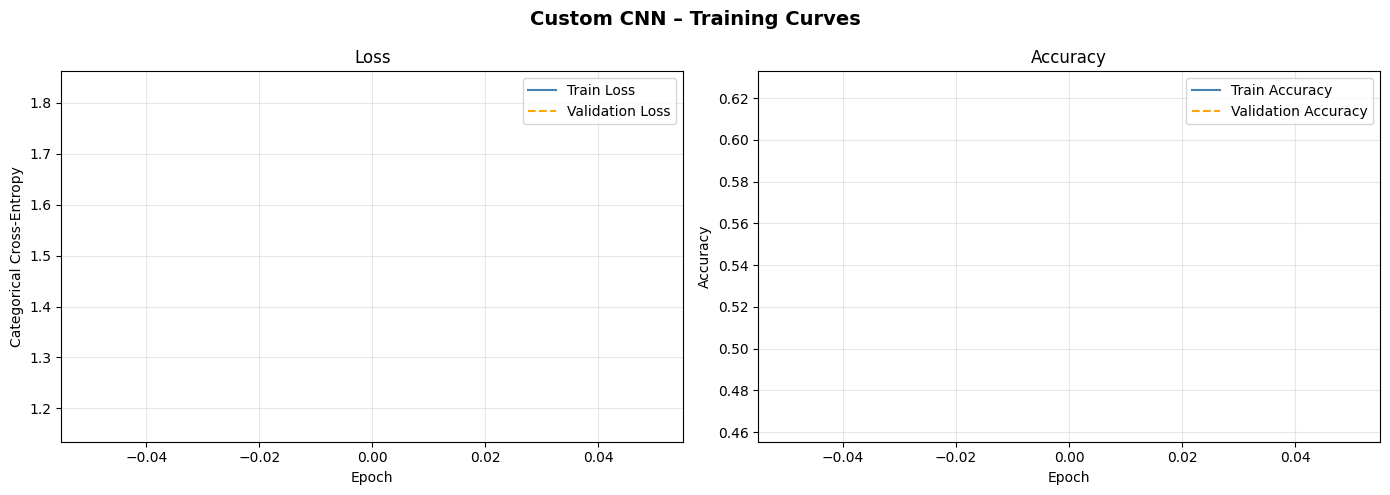

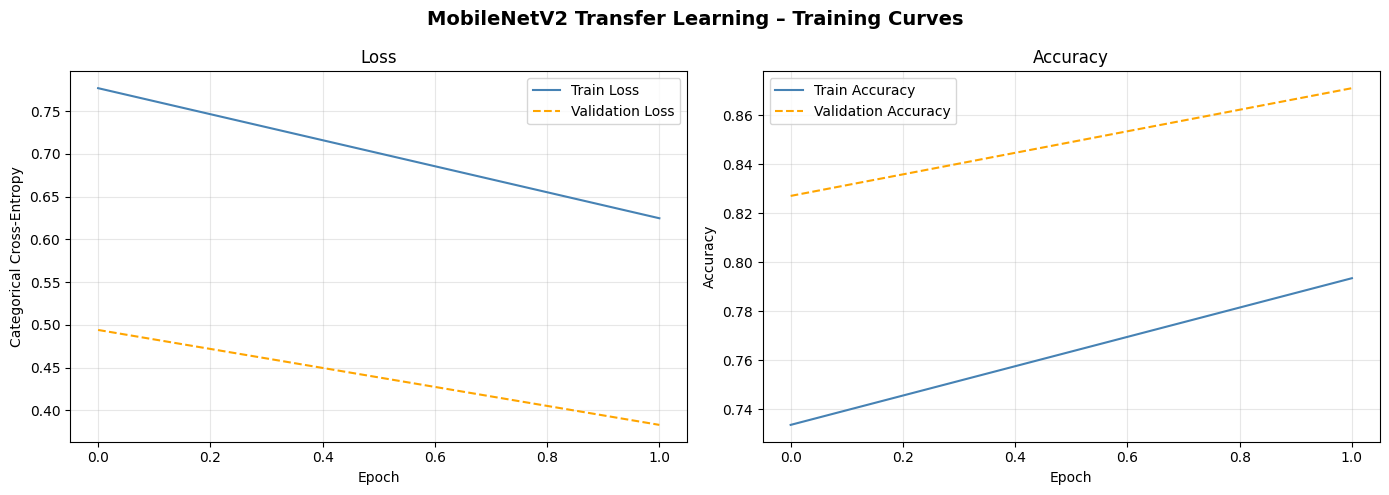

In [28]:
#8PLOT TRAINING CURVE
def plot_training_curves(history, title, filename):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Loss
    ax1.plot(history.history['loss'],     label='Train Loss',      color='steelblue')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Categorical Cross-Entropy')
    ax1.legend(); ax1.grid(alpha=0.3)

    # Accuracy
    ax2.plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


plot_training_curves(history_cnn, 'Custom CNN – Training Curves',
                     'custom_cnn_curves.png')

# Combine feature-extraction and fine-tuning histories
def combine_histories(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    class FakeHistory:
        def __init__(self, d): self.history = d
    return FakeHistory(combined)

history_tl = combine_histories(history_fe, history_ft)
plot_training_curves(history_tl, 'MobileNetV2 Transfer Learning – Training Curves',
                     'transfer_learning_curves.png')

In [21]:
#9EVALUATION ON TEST SET
def evaluate_model(model, X_test, y_test_oh, y_test_raw, model_name):
    """Compute and display all evaluation metrics."""
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true      = y_test_raw.flatten()

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')

    print(f'\n{"═"*50}')
    print(f'  {model_name}')
    print(f'{"═"*50}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'{"═"*50}')
    print('\nPer-Class Report:')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    return y_pred, {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


y_pred_cnn, metrics_cnn = evaluate_model(custom_cnn,    X_test, y_test_oh, y_test, 'Custom CNN')
y_pred_tl,  metrics_tl  = evaluate_model(transfer_model, X_test, y_test_oh, y_test, 'MobileNetV2 Transfer Learning')


══════════════════════════════════════════════════
  Custom CNN
══════════════════════════════════════════════════
  Accuracy  : 0.4593  (45.93%)
  Precision : 0.6649
  Recall    : 0.4593
  F1-Score  : 0.4897
══════════════════════════════════════════════════

Per-Class Report:
              precision    recall  f1-score   support

    airplane       0.94      0.31      0.46      1000
  automobile       0.93      0.50      0.65      1000
        bird       0.63      0.34      0.44      1000
         cat       0.42      0.26      0.32      1000
        deer       0.46      0.38      0.41      1000
         dog       0.66      0.26      0.37      1000
        frog       0.20      0.98      0.34      1000
       horse       0.82      0.49      0.61      1000
        ship       0.86      0.58      0.69      1000
       truck       0.74      0.51      0.60      1000

    accuracy                           0.46     10000
   macro avg       0.66      0.46      0.49     10000
weighted avg    

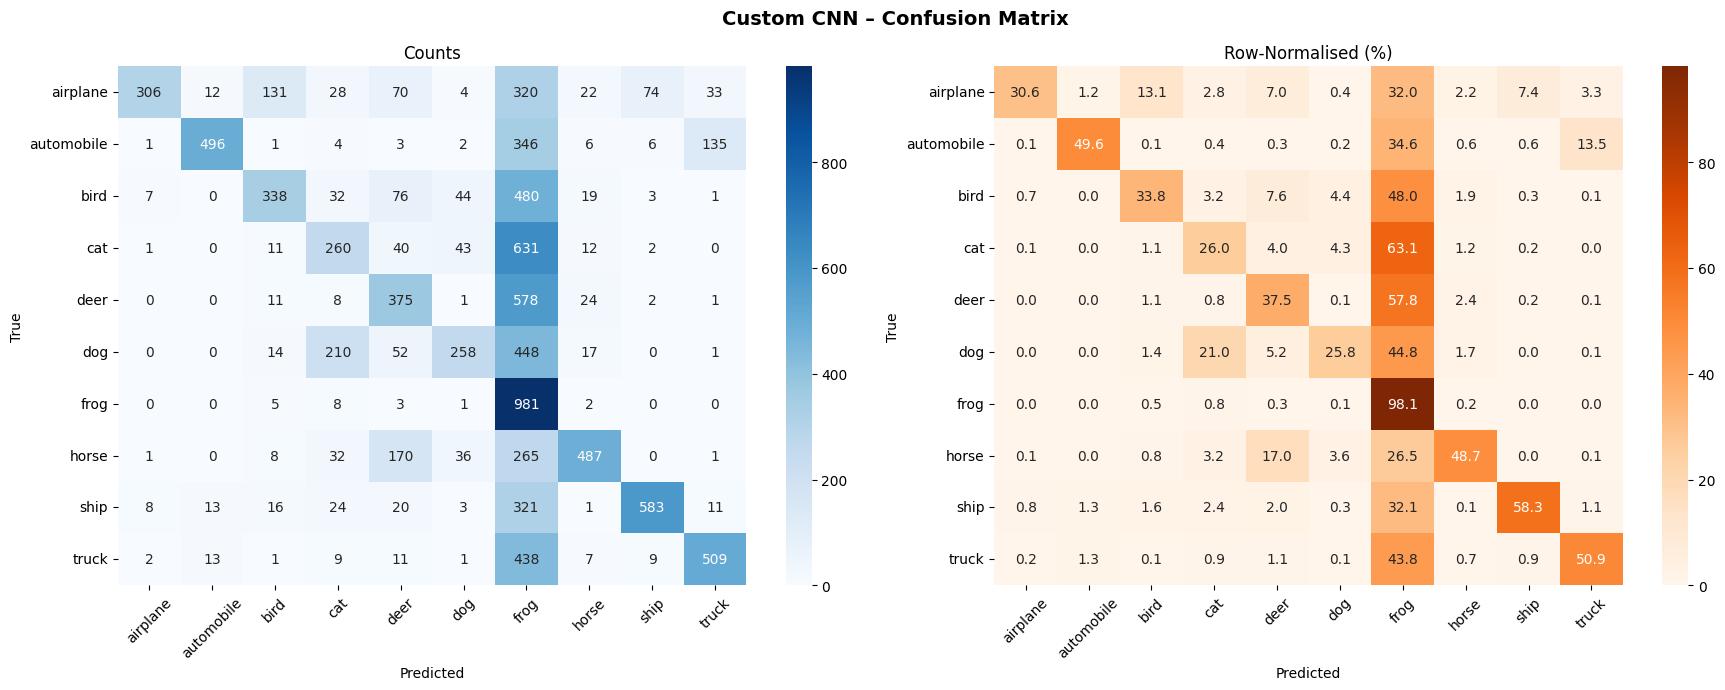

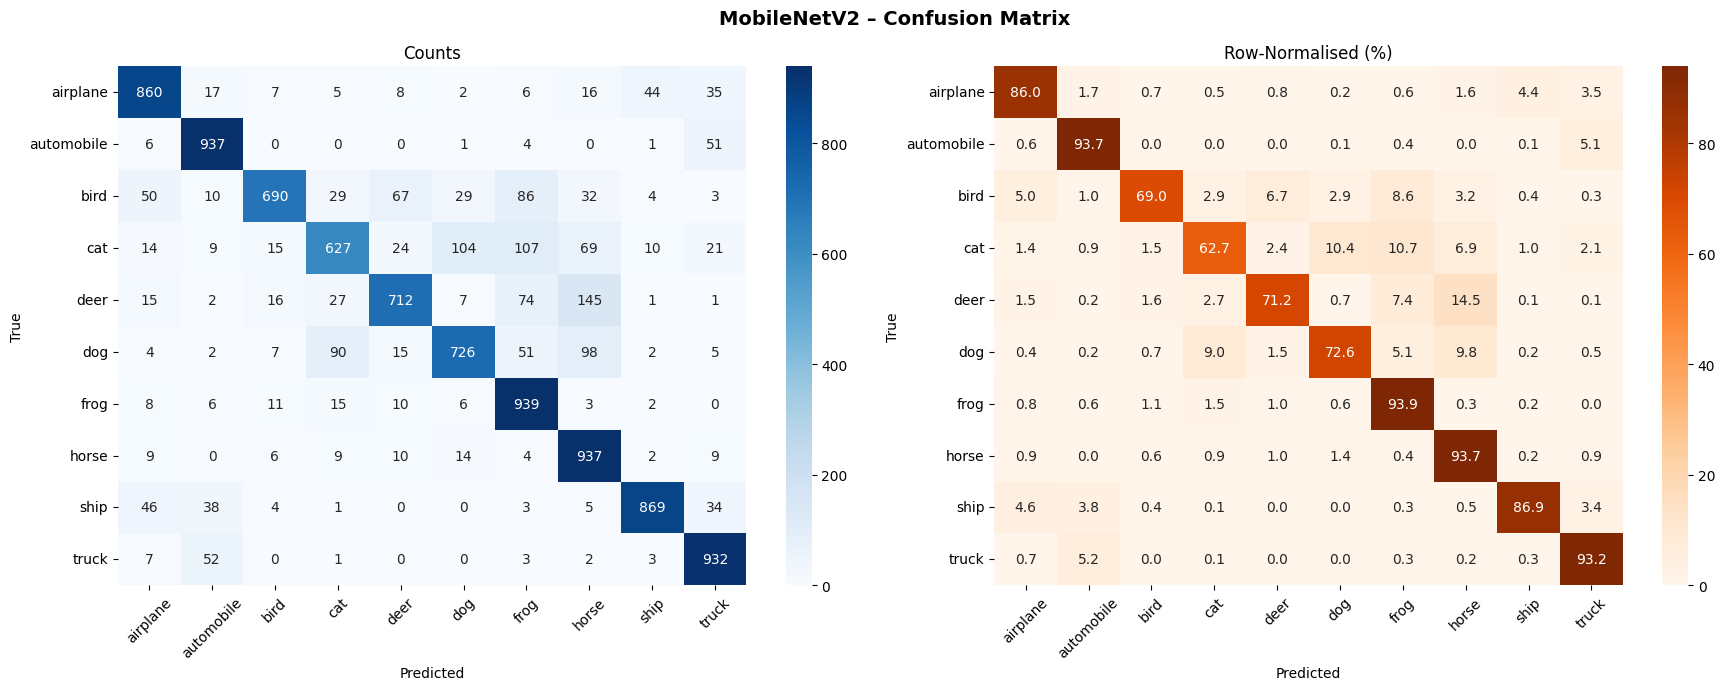

In [22]:
#10CONFUSION MATRICES
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_title('Counts'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', rotation=45)

    # Percentages
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Oranges',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[1].set_title('Row-Normalised (%)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


y_true_flat = y_test.flatten()
plot_confusion_matrix(y_true_flat, y_pred_cnn, 'Custom CNN – Confusion Matrix',
                      'cm_custom_cnn.png')
plot_confusion_matrix(y_true_flat, y_pred_tl,  'MobileNetV2 – Confusion Matrix',
                      'cm_transfer.png')


───────────────────────────────────────────────────────
Metric               Custom CNN       MobileNetV2 TL
───────────────────────────────────────────────────────
Accuracy                 0.4593               0.8229
Precision                0.6649               0.8301
Recall                   0.4593               0.8229
F1                       0.4897               0.8202
───────────────────────────────────────────────────────


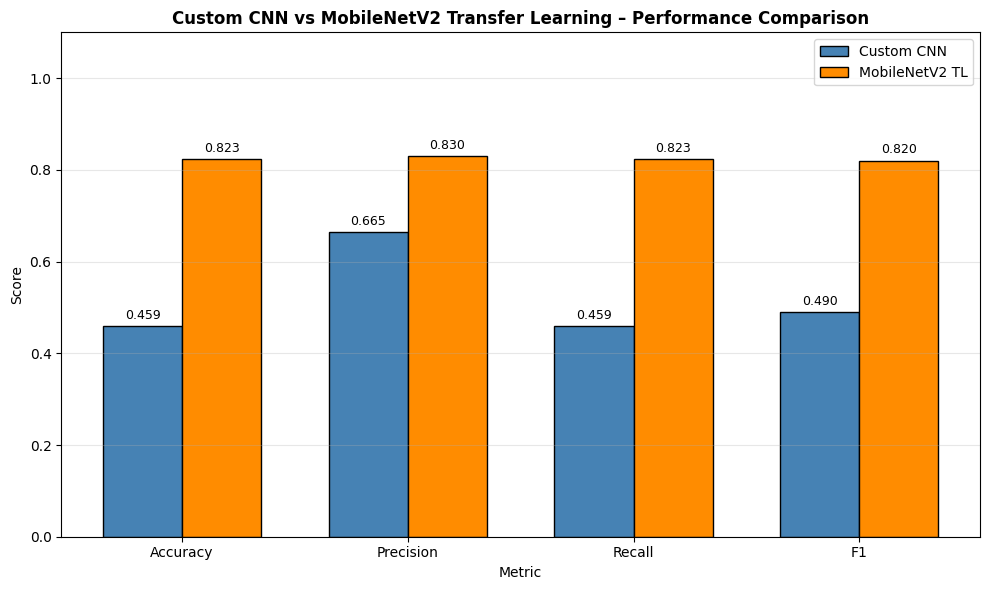

In [23]:
#11MODEL COMPARISON
models_names = ['Custom CNN', 'MobileNetV2 TL']
metric_keys  = ['accuracy', 'precision', 'recall', 'f1']
all_metrics  = [metrics_cnn, metrics_tl]

# ── Table ─────────────────────────────────────────────────────────────────────
print('\n' + '─'*55)
print(f'{"Metric":<15} {"Custom CNN":>15} {"MobileNetV2 TL":>20}')
print('─'*55)
for k in metric_keys:
    print(f'{k.capitalize():<15} {metrics_cnn[k]:>15.4f} {metrics_tl[k]:>20.4f}')
print('─'*55)

# ── Bar chart ─────────────────────────────────────────────────────────────────
x = np.arange(len(metric_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [metrics_cnn[k] for k in metric_keys], width,
               label='Custom CNN', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, [metrics_tl[k] for k in metric_keys],  width,
               label='MobileNetV2 TL', color='darkorange', edgecolor='black')

ax.set_xlabel('Metric'); ax.set_ylabel('Score')
ax.set_title('Custom CNN vs MobileNetV2 Transfer Learning – Performance Comparison',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([k.capitalize() for k in metric_keys])
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

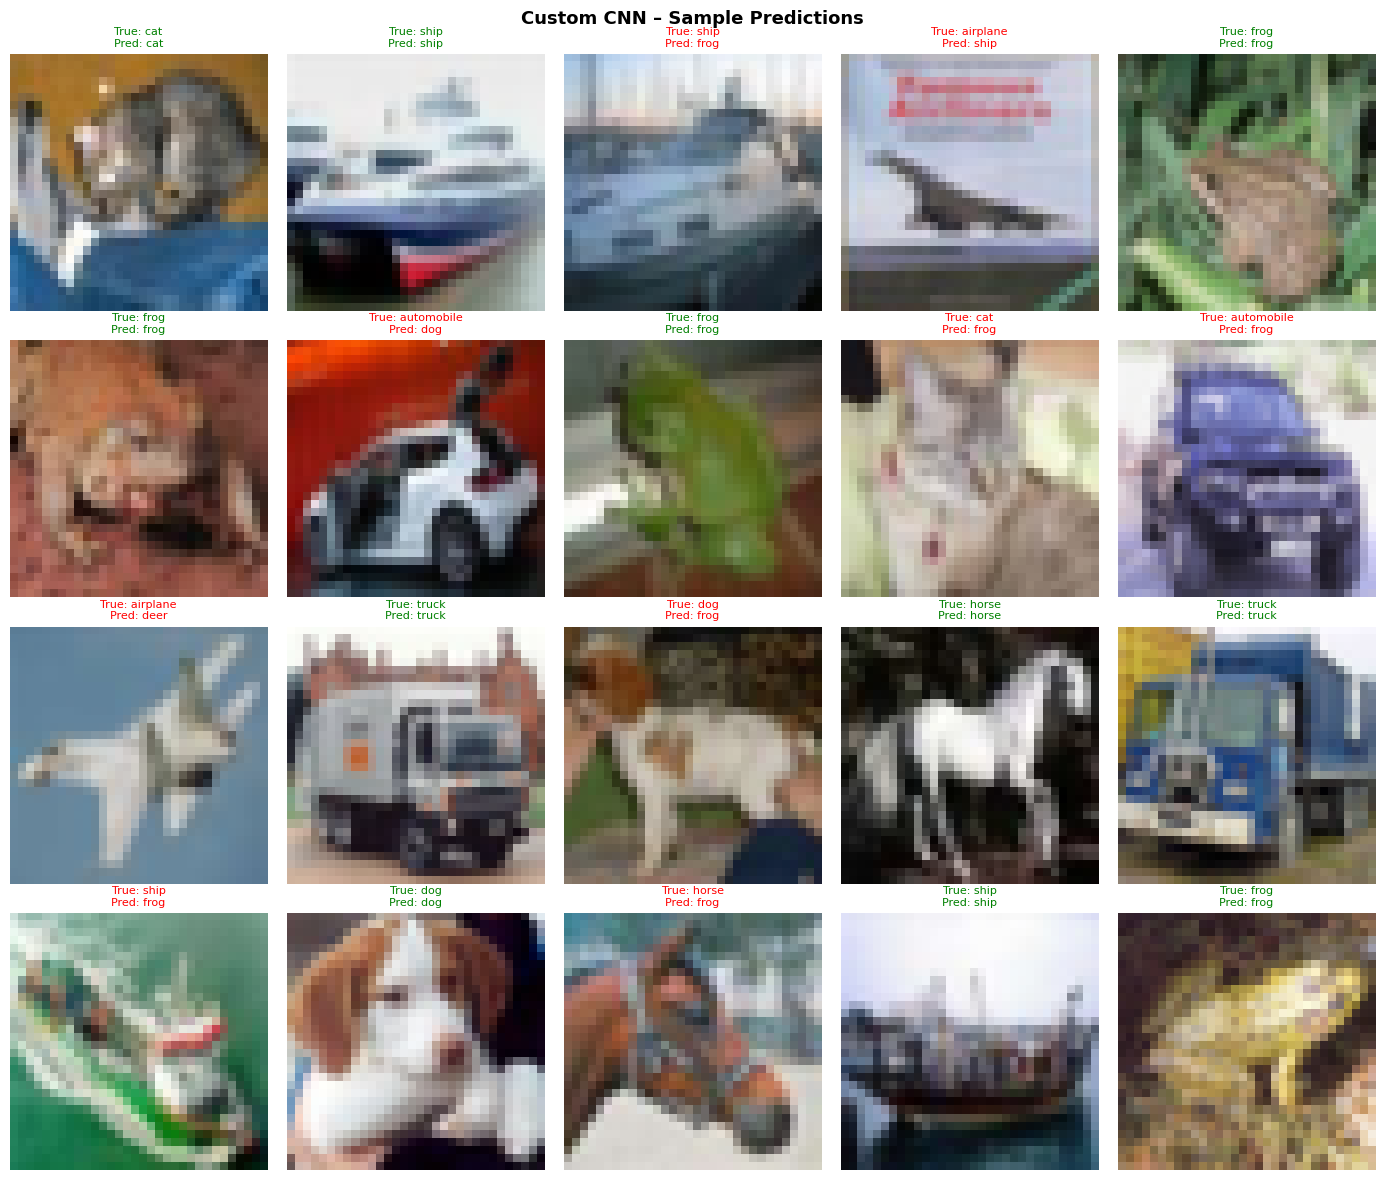

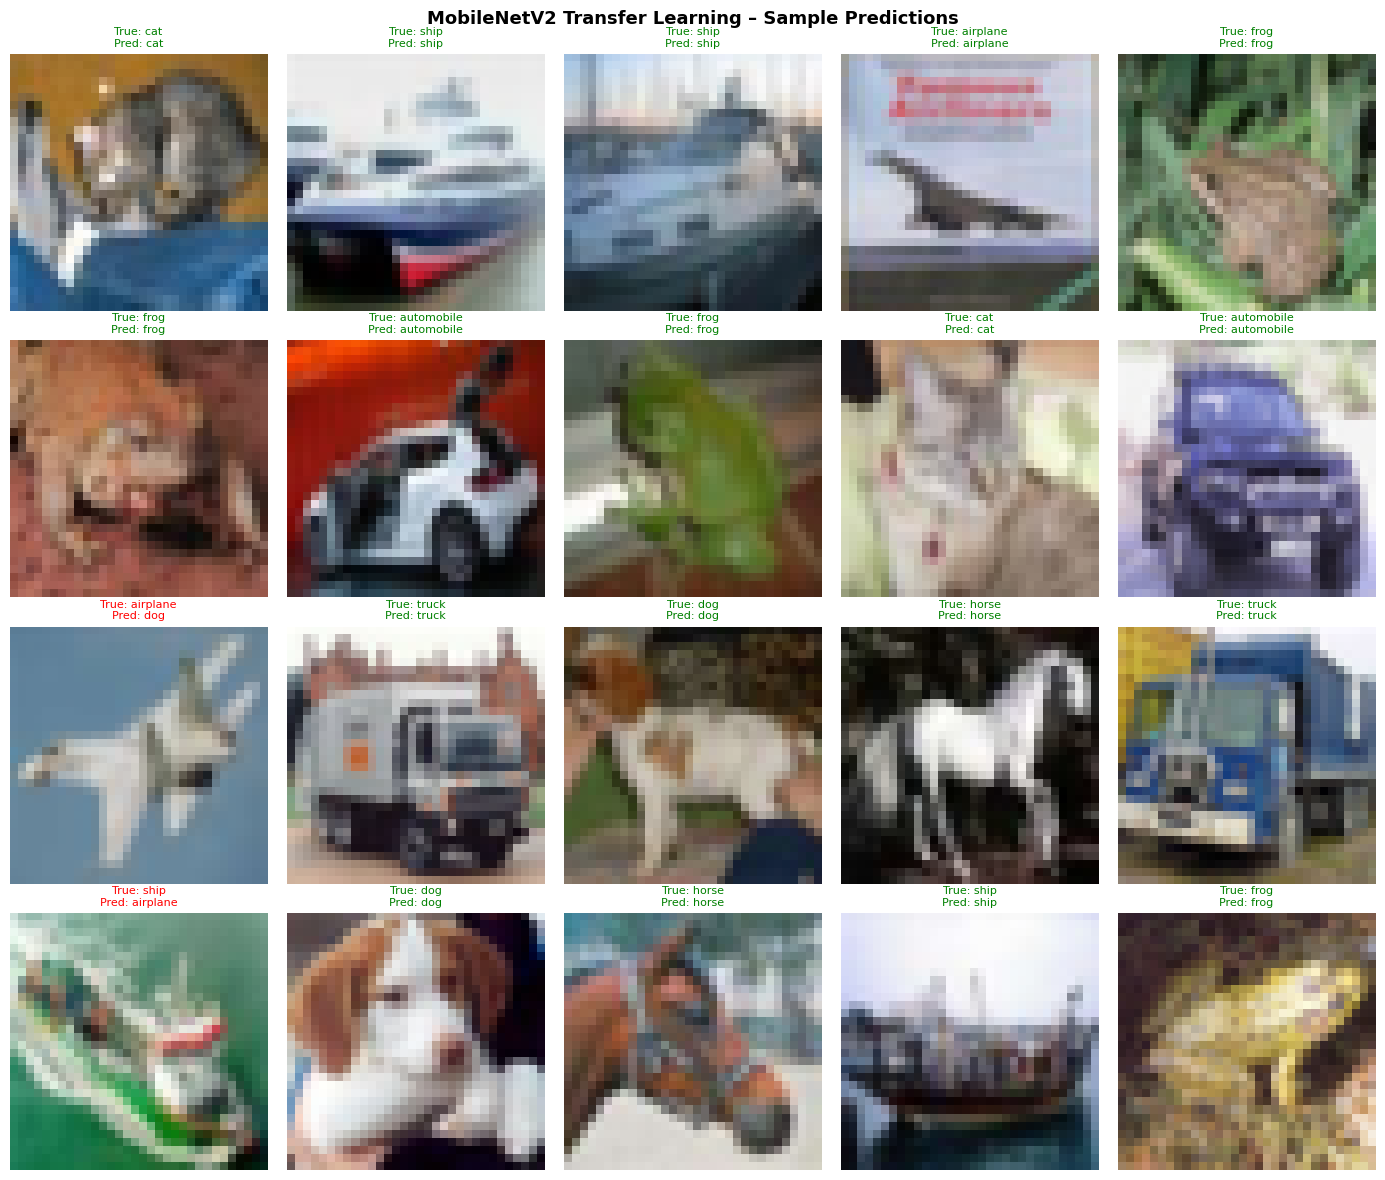

In [24]:
#12VISUAL PREDICTION
def visualise_predictions(model, X, y_true, model_name, n=20):
    y_pred_prob = model.predict(X[:n], verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    y_true_flat = y_true[:n].flatten()

    fig, axes = plt.subplots(4, 5, figsize=(14, 12))
    fig.suptitle(f'{model_name} – Sample Predictions', fontsize=13, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[i])
        correct = y_pred[i] == y_true_flat[i]
        color   = 'green' if correct else 'red'
        ax.set_title(
            f'True: {CLASS_NAMES[y_true_flat[i]]}\nPred: {CLASS_NAMES[y_pred[i]]}',
            color=color, fontsize=8
        )
        ax.axis('off')
    plt.tight_layout()
    fname = model_name.replace(' ', '_').lower() + '_predictions.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


visualise_predictions(custom_cnn,     X_test, y_test, 'Custom CNN')
visualise_predictions(transfer_model, X_test, y_test, 'MobileNetV2 Transfer Learning')